# Сбор данных

С начала нужны данные.

**"Мусор на входе - мусор на выходе"**

Ни какой новый супермодный метод не сможет компенсировать плохое качество исходных данных

В Jupyter/Colab `!` позволяет выполнять команды оболочки (shell).
Сначала нужно установить некоторые пакеты.


In [ ]:
!pip install apimoex
!pip install yfinance
!pip install plotly
!pip install quandl
!pip install mplfinance
!pip install ffn
!pip install scipy
!pip install statsmodels
!pip install seaborn

### Yahoo Finance

[Yahoo Finance](https://finance.yahoo.com/) — популярный веб-сайт, содержащий финансовые новости и финансовые данные (исторические и текущие цены акций и другие данные). Также можно загрузить фундаментальные данные, включая финансовую отчетность компаний, баланс и денежные потоки, а также данные по опционам.

Библиотека `yfinance` - один из  простых способов получить данные Yahoo Finance в Python.

1. Импортируем библиотеки

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance
import numpy as np

import apimoex
import ffn
import quandl
from datetime import date
import datetime
import requests

today = date.today()
today # текущая дата

datetime.date(2026, 1, 14)

In [4]:
AAPL = yf.Ticker("AAPL")
AAPL

yfinance.Ticker object <AAPL>

In [5]:
print(AAPL.financials)

Empty DataFrame
Columns: []
Index: []


В последнее время сервис Yahoo Finance стал работать ненадежно. Поэтому будьте аккуратны при использовании. 

In [6]:

# Получаем данные по акции AAPL
df = yf.download('AAPL','2023-01-01', today)
print(f"Загружено {len(df)} строк данных.")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Загружено 0 строк данных.


In [11]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,


### pandas-datareader

[`pandas-datareader`](https://pandas-datareader.readthedocs.io/en/latest/) это отдельная библиотека, которая "подтягивает" данные из ряда внешних источников в формат pandas.DataFrame.

`pandas-datareader` предоставляет доступ к [FRED](https://fred.stlouisfed.org/). 

База данных FRED (Federal Reserve Economic Data) - это удобный онлайн-ресурс, предоставляющий экономические данные из различных национальных и международных источников. Но преимущественно это статистика США. 

Но `pandas-datareader` давно не поддерживается. Поэтому может рано или поздно сломаться.


In [9]:
import pandas_datareader as pdr

In [10]:
df = pdr.get_data_fred('UNRATE').dropna()
df.rename(columns = {'UNRATE' : "Unemployment Rate"})

,Unemployment Rate
DATE,
2021-02-01,6.2
2021-03-01,6.1
2021-04-01,6.1
2021-05-01,5.8
2021-06-01,5.9
2021-07-01,5.4
2021-08-01,5.1
2021-09-01,4.7
2021-10-01,4.5


In [13]:
from datetime import date
start = date(2000, 1, 4)
tb3 = pdr.get_data_fred('DTB3', start = start).dropna()

In [14]:
tb3 # что это за серия?


,DTB3
DATE,
2000-01-04,5.27
2000-01-05,5.28
2000-01-06,5.25
2000-01-07,5.22
2000-01-10,5.24
...,...
2026-01-06,3.53
2026-01-07,3.52
2026-01-08,3.52


### ЗАДАНИЕ 1

- зайтите на сайт FRED
- изучите какие источники там есть 
- найдите интересный для вас индикатор 
- скачайте его с помощью пакаета `pandas_datareader`
- постройте график этой серии 

`pandas_datareader` позволяет также получать данные по ценам на акциям США. 

In [15]:
df = pdr.DataReader("AAPL", "stooq")  # дневные OHLCV
df

,Open,High,Low,Close,Volume
Date,,,,,
2026-01-13,258.720,261.810,258.390,261.050,45730847
2026-01-12,259.160,261.300,256.800,260.250,45263767
2026-01-09,259.075,260.210,256.220,259.370,39996967
2026-01-08,257.020,259.290,255.700,259.040,50419337
2026-01-07,263.200,263.680,259.810,260.330,48309804
...,...,...,...,...,...
2021-01-22,133.123,136.601,131.881,135.831,117180154
2021-01-21,130.696,136.423,130.490,133.704,123394633
2021-01-20,125.671,129.415,125.562,128.962,106799252


### SEC EDGAR API

Если нужны данные из финансовой отчетности по публиячным компаням в США, это один из самых "чистых" бесплатных вариантов: данные из отчетности, в JSON. 

У SEC есть официальные REST API на data.sec.gov, в том числе companyfacts (XBRL-факты по компании).

**Минусы**: 

- нужно уметь сопоставлять тикер и CIK 
- аккуратно работать с заголовками и частотой запросов (SEC это просит)
- уметь работатать с отчетами разных типав и извлекать отттуда показатели 

In [48]:
# !pip install -U sec-edgar-api

In [49]:
from sec_edgar_api import EdgarClient

# Specify user-agent string to pass to SEC to identify
# requests for rate-limiting purposes
edgar = EdgarClient(user_agent="<Sample Company Name> <Admin Contact>@<Sample Company Domain>")


In [ ]:
# Get company concept for Apple
edgar.get_company_concept(cik="320193", taxonomy="us-gaap", tag="AccountsPayableCurrent")

{'cik': 320193,
 'taxonomy': 'us-gaap',
 'tag': 'AccountsPayableCurrent',
 'label': 'Accounts Payable, Current',
 'description': "Carrying value as of the balance sheet date of liabilities incurred (and for which invoices have typically been received) and payable to vendors for goods and services received that are used in an entity's business. Used to reflect the current portion of the liabilities (due within one year or within the normal operating cycle if longer).",
 'entityName': 'Apple Inc.',
 'units': {'USD': [{'end': '2008-09-27',
    'val': 5520000000,
    'accn': '0001193125-09-214859',
    'fy': 2009,
    'fp': 'FY',
    'form': '10-K',
    'filed': '2009-10-27'},
   {'end': '2008-09-27',
    'val': 5520000000,
    'accn': '0001193125-10-012091',
    'fy': 2009,
    'fp': 'FY',
    'form': '10-K/A',
    'filed': '2010-01-25',
    'frame': 'CY2008Q3I'},
   {'end': '2009-09-26',
    'val': 5601000000,
    'accn': '0001193125-09-214859',
    'fy': 2009,
    'fp': 'FY',
    'form'

In [ ]:
edgar.get_company_facts(cik="320193")

### dbnomics

`dbnomics` является удобные агрегатором разничной экономической статистики. 

Сервис создан во Франции, поэтому там большое количество источников по европейской статистике (ЕС, ЕЦБ и проч.)

In [ ]:
# !pip install dbnomics

In [16]:
from dbnomics import fetch_series, fetch_series_by_api_link

In [17]:
df = fetch_series('ECB/EST/B.EU000A2QQF16.CR')
df

,@frequency,provider_code,dataset_code,dataset_name,series_code,series_name,original_period,period,original_value,value,FREQ,BENCHMARK_ITEM,DATA_TYPE_EST,Frequency,Benchmark item,Data type in the Euro short-term rate context
0,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2019-10-08,2019-10-08,-0.55255,-0.55255,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
1,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2019-10-09,2019-10-09,-0.55298,-0.55298,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
2,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2019-10-10,2019-10-10,-0.55312,-0.55312,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
3,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2019-10-11,2019-10-11,-0.55269,-0.55269,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
4,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2019-10-14,2019-10-14,-0.55141,-0.55141,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2025-01-27,2025-01-27,2.92132,2.92132,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
1360,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2025-01-28,2025-01-28,2.92161,2.92161,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
1361,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2025-01-29,2025-01-29,2.92161,2.92161,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate
1362,daily,ECB,EST,Euro Short-Term Rate,B.EU000A2QQF16.CR,Daily - businessweek – Euro Short-Term Rate - ...,2025-01-30,2025-01-30,2.92204,2.92204,B,EU000A2QQF16,CR,Daily - businessweek,Euro Short-Term Rate - 1-week Compounded Avera...,Compounded average rate


### quandl 

**Quandl** был крупнейшим агрегатором финансовых и экономических временных рядов.
С 2018 года принадлежит Nasdaq и сейчас официальное название сервиса **Nasdaq Data Link**.

Он предоставляет:

- Макроэкономику: ФРС (FRED), Всемирный банк, OECD
- Финансовые рынки: акции, индексы, фьючерсы
- Сырьё: нефть, газ, металлы, агро
- Альтернативные данные: перевозки, спутники, трафик (платно)

Исторически это части использовался для академических и квант-проектов, но стал хуже в последние годы.

### Архитектура 

Каждый набор данных имеет код вида: `SOURCE/DATASETэ


In [29]:
import nasdaqdatalink as ndl
ndl.ApiConfig.api_key = "API_KEY" # нужно получить свой ключ, бесплатно


In [ ]:
wti = ndl.get("EIA/PET_RWTC_D") # цены на нефть 

DataLinkError: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.

In [ ]:
wti.rename(columns={"Value": "WTI"}, inplace=True)
wti.plot()


DataLinkError: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.

### apimoex

Yahoo Finance и Quandl в основном содержат цены акций и другие данные для американских и европейских компаний.
Чаще всего нам может понадобиться получить данные по российским компаниям и данным с российского фондового рынка.

`apimoex` —  библиотека, которая помогает получать данные с Московской биржи. По сути то Python-обертка над официальным API Московской биржи ISS.


In [30]:
import apimoex

with requests.Session() as session:           # создается http-сессия
    data = apimoex.get_board_history(session, 'LKOH')
    df = pd.DataFrame(data)
    df.set_index('TRADEDATE', inplace=True)
    print(df.head(), '\n')
    print(df.tail(), '\n')
    df.info()



           BOARDID   CLOSE  VOLUME       VALUE
TRADEDATE                                     
2013-03-25    TQBR  1922.0   32441  62920708.6
2013-03-26    TQBR  1944.5    3653   7035671.0
2013-03-27    TQBR  1969.7    1924   3738545.3
2013-03-28    TQBR  1993.2    3398   6719742.2
2013-03-29    TQBR  2003.4    1908   3814674.4 

           BOARDID   CLOSE   VOLUME         VALUE
TRADEDATE                                        
2026-01-06    TQBR  5884.0   392916  2.314325e+09
2026-01-08    TQBR  5851.5   661639  3.868542e+09
2026-01-09    TQBR  5878.0   605775  3.543069e+09
2026-01-12    TQBR  5393.0  2022616  1.106989e+10
2026-01-13    TQBR  5392.5   747154  4.027574e+09 

<class 'pandas.core.frame.DataFrame'>
Index: 3234 entries, 2013-03-25 to 2026-01-13
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BOARDID  3234 non-null   object 
 1   CLOSE    3216 non-null   float64
 2   VOLUME   3234 non-null   int64  
 3   VALUE 

In [ ]:
ticker = "SBER"

data = apimoex.get_market_candles(session = session,
                                  security = ticker,
                                  interval = 60,
                                  start = '2025-12-01',
                                  end = today)
sber = pd.DataFrame(data)

`interval` : размер свечки - целое число 1 (1 минута), 10 (10 минут), 60 (1 час), 24 (1 день), 7 (1 неделя), 31 (1 месяц) или 4 (1 квартал). 

По умолчанию дневные данные.

sber
sber['begin'] = pd.DatetimeIndex(sber['begin'])
sber.rename({'begin':'date', 'value':'value_rub'}, axis='columns', inplace = True)
sber.set_index('date', inplace=True)

sber
Обернем это в функцию
def get_moex_stock(ticker, start = '2023-01-01', end = None):
  if end is None:
    end = today
  data = apimoex.get_market_candles(session = session, security = ticker, start = start,  end = end)
  df = pd.DataFrame(data)
  df['begin'] = pd.DatetimeIndex(df['begin'])
  df.rename({'begin':'date', 'value':'value_rub'}, axis='columns', inplace = True)
  df.set_index('date', inplace=True)
  df['volume'] = df['volume'].astype('float64')
  return df

sber = get_moex_stock("SBER", start = '2021-01-01', end = today)
sber
sber.to_excel('sber_data.xlsx', index=True)
from google.colab import files

# Скачать Excel файл
files.download('sber_data.xlsx')


### moexutils 



Библиотека ``moexutils` предоставляет расширенные возможности:

- **Локальное сохранение и обновление файлов** в формате `parquet`
- **Расчет корректировки на дивиденды**
- **Расчет рыночной капитализации** с помощью данных Мосбиржи
- **Получение данных по индексам** 


In [19]:
import moex_utils as moex

ticker = "LKOH"
df = moex.get_moex_stock(ticker, start='2000-01-01')
df.tail()

,open,close,high,low,value_rub,volume,ticker
date,,,,,,,
2026-01-09,5848.0,5878.0,5882.0,5821.0,3.543069e+09,605775.0,LKOH
2026-01-12,5520.0,5393.0,5550.0,5363.0,1.106989e+10,2022616.0,LKOH
2026-01-13,5385.0,5392.5,5430.0,5352.0,4.027574e+09,747154.0,LKOH
2026-01-14,5395.0,5386.0,5429.0,5352.0,3.648758e+09,676492.0,LKOH
2026-01-15,5392.0,5408.0,5409.0,5366.0,9.542707e+08,177128.0,LKOH


In [42]:
print("Доступные функции в moexutils:")
print([attr for attr in dir(moex) if not attr.startswith('_')])


Доступные функции в moexutils:
['DATA_FOLDER', 'METADATA_FILE', 'add_adj_close_to_all_stocks', 'add_market_cap_to_all_stocks', 'apimoex', 'calculate_adj_close', 'calculate_market_cap', 'combine_moex_stocks', 'datetime', 'get_moex_index', 'get_moex_stock', 'load_shares_data', 'np', 'os', 'pd', 'read_moex_stock', 'requests', 'save_moex_stock', 'update_all_stocks', 'update_moex_stock']


### ЗАДАНИЕ 2 

- скачайте цены на акции своего тикера 
- посмотрите, какая первая начальная дата
- постройте график 
- подумайте, чем может быть объясняться динамика цен на акции вашего тикера

# Предобработка данных (preproccessing)

## Работа с датами

- Финансовые данные пракически всегда имееют временную привязку -> работа с датама важны
- Частность может быть разной - дневная, месячная, квартальная, годовая
- В мире есть часовые поясы. Нужно их корректно учитывать, чтобы узбежать "утечек" (leakage)
- Даты могут храниться по разному: 2025-01-02 (2 января или 1 февраля?)
- Даты особенно важны, если объединяются данных из разных источников (к примеру, цена акций и макроэкономическая статистика)   

In [1]:
from datetime import datetime, date, timedelta

d = datetime(2025, 1, 15, 15, 30)
d + timedelta(days=5)

datetime.datetime(2025, 1, 20, 15, 30)

Ключевые вещи:

- `date` хранит только календарную дату
- `datetime` хранит дату и время
- `timedelta` это сдвиги

In [ ]:
# ! pip install arrow


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Примечание: у нас есть несколько возможностей для работы с датами в Python

# почему год первым?
dt1 = (2022, 10, 11)
dt2 = (2022, 10, 17)

dt3 = "2023-03-17"
dt4 = "2023-03-25"

from datetime import date   # https://docs.python.org/3/library/datetime.html
                            # https://aboutsimon.com/blog/2013/06/06/Datetime-hell-Time-zone-aware-to-UNIX-timestamp.html
dt5 = date(2024, 11, 25)
dt6 = date(2024, 11, 29)

import arrow                # https://arrow.readthedocs.io/en/latest/
dt7 = arrow.get(2024, 11, 19)
dt8 = arrow.get("2024-11-26")

import pandas as pd         # https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.html
dt9 = pd.Timestamp("2025-11-01")
dt10 = pd.Timestamp("2025-11-07")
dt_now = pd.Timestamp.now(tz="Europe/Moscow")

# Почему даты сложны?
# - ...
# - ...
# - ...

# Почему несколько библиотек?
# - лучшие интерфейсы ("для людей")

# Идеи для практики:
# - какой сегодня день?
# - конвертация между типами дат
# - сохранение как строка, чтение из строки
# - дельты
# - диапазоны
# - календари


In [3]:
t1 = pd.Timestamp('2025-11-15')
t2 = pd.Timestamp('2025-11-19')
t1, t2

(Timestamp('2025-11-15 00:00:00'), Timestamp('2025-11-19 00:00:00'))

In [4]:
(t2-t1).days

4

In [5]:
t1.isoformat()


'2025-11-15T00:00:00'

In [6]:
now = arrow.now()
tomorrow = now.shift(days=1)
last_week = now.shift(weeks=-1)

print(tomorrow)
print(last_week)

2026-01-16T14:01:59.925128+03:00
2026-01-08T14:01:59.925128+03:00


In [8]:
some_date = arrow.get('2022-11-05')
print(some_date.humanize())  # Вывод: "3 years ago"


3 years ago


`arrow` упрощает работу с диапазонами дат. 

Это может быть особенно полезно для анализа исторических данных, создания отчетов на основе времени или любых задач, требующих итерации по датам:


In [ ]:
start = arrow.get('2024-11-01')
end = arrow.get('2024-11-10')
for r in arrow.Arrow.range('day', start, end):
    print(r.format('YYYY-MM-DD'))


In [9]:
arrow.get("20250115", "YYYYMMDD")
arrow.get("15.01.2025", "DD.MM.YYYY")
arrow.get("2025-01-15T14:30:00-05:00")

<Arrow [2025-01-15T14:30:00-05:00]>

In [12]:
# концертация часовых поясов 
ny = arrow.get("2025-01-15 09:30", "YYYY-MM-DD HH:mm").replace(tzinfo="US/Eastern")
utc = ny.to("UTC")

print(ny)
print(utc)

2025-01-15T09:30:00-05:00
2025-01-15T14:30:00+00:00


In [16]:
t = arrow.get("2025-02-12")

t.floor("month")   # начало месяца

<Arrow [2025-02-01T00:00:00+00:00]>

In [15]:
t.ceil("month")    # конец месяца


<Arrow [2025-02-28T23:59:59.999999+00:00]>

## Изменение частоты ряда (ресемплинг)

Вы всегда можете преобразовать из более низкой частоты в более высокую, т.е. из дневных данных в месячные.

В Python можно использовать метод resample из pandas.


In [20]:
df['close'].resample('MS').mean()

date
2003-08-01     588.073750
2003-09-01     590.779091
2003-10-01     669.278696
2003-11-01     628.303158
2003-12-01     662.761905
                 ...     
2025-09-01    6349.321429
2025-10-01    5935.379310
2025-11-01    5309.750000
2025-12-01    5700.071429
2026-01-01    5633.062500
Freq: MS, Name: close, Length: 270, dtype: float64

In [21]:
df['close'].resample('MS').ohlc()

,open,high,low,close
date,,,,
2003-08-01,581.00,595.99,581.00,595.99
2003-09-01,601.30,625.90,562.51,625.90
2003-10-01,637.61,721.00,584.00,609.50
2003-11-01,658.99,658.99,580.02,642.32
2003-12-01,636.11,681.00,636.11,677.00
...,...,...,...,...
2025-09-01,6370.00,6626.50,6082.50,6082.50
2025-10-01,6048.50,6419.50,5237.00,5443.00
2025-11-01,5475.00,5580.00,4886.00,5548.00


## Объединение данных из разных источников 

In [25]:
import pandas as pd
import pandas_datareader.data as pdr
import datetime as dt

start = dt.datetime(2020, 1, 1)
end   = dt.datetime(2025, 12, 31)

# 1) Макро из FRED
macro = pdr.DataReader(["CPIAUCSL", "FEDFUNDS"], "fred", start, end)
macro = macro.resample("M").last()  # привели к месячной частоте



C:\Users\m_salihov\AppData\Local\Temp\ipykernel_18088\418667639.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  macro = macro.resample("M").last()  # привели к месячной частоте


In [30]:
# 2) Акция из Stooq
aapl = pdr.DataReader("AAPL", "stooq", start, end)
aapl = aapl[["Close"]].rename(columns={"Close": "AAPL_Close"}).resample("M").last()


ConnectionError: HTTPSConnectionPool(host='stooq.com', port=443): Read timed out.

In [31]:
# 3) Объединение
df = macro.join(aapl, how="inner")
print(df.tail())

NameError: name 'aapl' is not defined

### Лог-доходности в финансовых данных

В количественных финансах доходности почти всегда считаются не в процентах, а в **лог-доходностях**. Это не вопрос вкуса, а следствие математики временных рядов и статистики.

Обозначим цену актива как (P_t).

Обычная доходность:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Лог-доходность:

$$ r_t = \ln(P_t) - \ln(P_{t-1}) = \ln\left(\frac{P_t}{P_{t-1}}\right)$$


Типовой код на pandas:

```python
import numpy as np

prices = df["Close"]

simple_returns = prices.pct_change()
log_returns = np.log(prices).diff()
```

Это математически эквивалентно:

```python
log_returns = np.log(prices / prices.shift(1))
```

---

Почему лог-доходности фундаментально удобнее

**Аддитивность во времени**

Для обычных доходностей:

$$(1 + R_1)(1 + R_2) \neq 1 + R_1 + R_2$$


Для лог-доходностей:

$$r_1 + r_2 = \ln\left(\frac{P_1}{P_0}\right) + \ln\left(\frac{P_2}{P_1}\right)= \ln\left(\frac{P_2}{P_0}\right)$$

Это означает:

> доходность за месяц = сумма дневных лог-доходностей


** Нормальность распределений**

Эмпирический факт: цены имеют правый хвост и нестационарны, а лог-доходности ближе к стационарным и симметричным.

В  большинстве стохастических моделей предполагается:

$$ \ln(P_t) \sim \text{случайное блуждание} $$

то есть доходности логарифмические, а не простые.

**Инвариантность к масштабу**

Если  умножить цену на 100 (рубли вместо копеек), лог-доходности не изменятся:

$$ \ln(100 P_t) - \ln(100 P_{t-1}) = \ln(P_t) - \ln(P_{t-1}) $$ 

Обычные доходности формально тоже масштабно-инвариантны, но в моделях с лог-ценами это дает линейность.


Приближение обычных доходностей

Для малых изменений:

$$ \ln(1+R) \approx R $$

То есть для дневных доходностей:

* лог-доходность ≈ процентная доходность
* но при больших движениях они уже отличаются

Пример:

| Изменение цены | Простая доходность | Лог-доходность |
| -------------- | ------------------ | -------------- |
| +10%           | 0.10               | 0.0953         |
| −10%           | −0.10              | −0.1054        |

Обычные доходности не симметричны. Лог-доходности симметричны.

Ограничения лог-доходностей


1. Не определены при нулевой цене
2. Для дивидендов и купонов нужно использовать total return
3. Для кредитных инструментов и fixed income лог-доходности хуже работают

Поэтому для акций и индексов лог-доходности стандарт, а для облигаций часто используют доходности к погашению или price changes.


**За:**

* Аддитивность по времени
* Совместимость со стохастическими моделями
* Удобная работа с волатильностью

**Против:**

* Плохо работают с нулевыми ценами и выплатами
* Менее интуитивны для нефинансовой аудитории
* Не всегда подходят для fixed income



In [32]:
df

,open,close,high,low,value_rub,volume,ticker
date,,,,,,,
2003-08-20,592.13,581.0,592.13,572.00,7.329184e+08,1264649.0,LKOH
2003-08-21,581.79,589.5,594.00,580.11,6.243343e+08,1063215.0,LKOH
2003-08-22,590.00,589.0,593.00,577.12,4.810764e+08,820377.0,LKOH
2003-08-25,590.00,586.5,591.99,583.00,2.390592e+08,407418.0,LKOH
2003-08-26,587.00,581.0,588.00,573.30,5.099564e+08,879803.0,LKOH
...,...,...,...,...,...,...,...
2026-01-09,5848.00,5878.0,5882.00,5821.00,3.543069e+09,605775.0,LKOH
2026-01-12,5520.00,5393.0,5550.00,5363.00,1.106989e+10,2022616.0,LKOH
2026-01-13,5385.00,5392.5,5430.00,5352.00,4.027574e+09,747154.0,LKOH


In [34]:
import numpy as np 
df['simple_rtn'] = df['close'].pct_change()
df['log_rtn'] = np.log(df['close']) - np.log(df['close'].shift(1))

In [35]:
df.tail()

,open,close,high,low,value_rub,volume,ticker,simple_rtn,log_rtn
date,,,,,,,,,
2026-01-09,5848.0,5878.0,5882.0,5821.0,3.543069e+09,605775.0,LKOH,0.004529,0.004519
2026-01-12,5520.0,5393.0,5550.0,5363.0,1.106989e+10,2022616.0,LKOH,-0.082511,-0.086115
2026-01-13,5385.0,5392.5,5430.0,5352.0,4.027574e+09,747154.0,LKOH,-0.000093,-0.000093
2026-01-14,5395.0,5386.0,5429.0,5352.0,3.648758e+09,676492.0,LKOH,-0.001205,-0.001206
2026-01-15,5392.0,5408.0,5409.0,5366.0,9.542707e+08,177128.0,LKOH,0.004085,0.004076


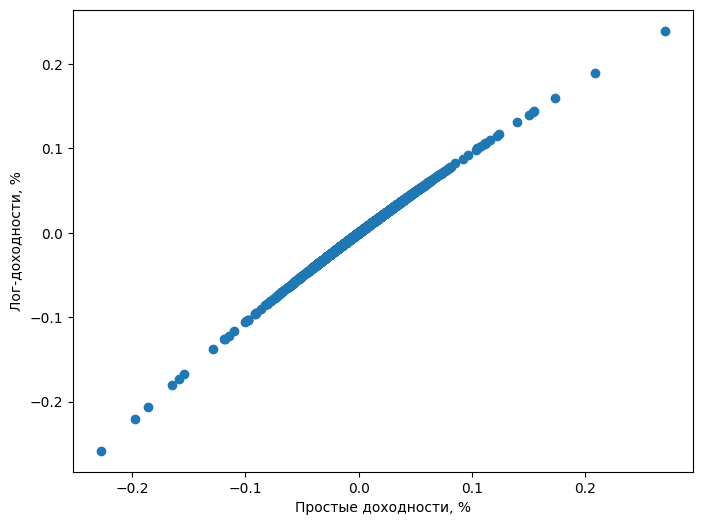

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x = df['simple_rtn'], y = df['log_rtn'])
plt.xlabel("Простые доходности, %")
plt.ylabel("Лог-доходности, %")
plt.show()


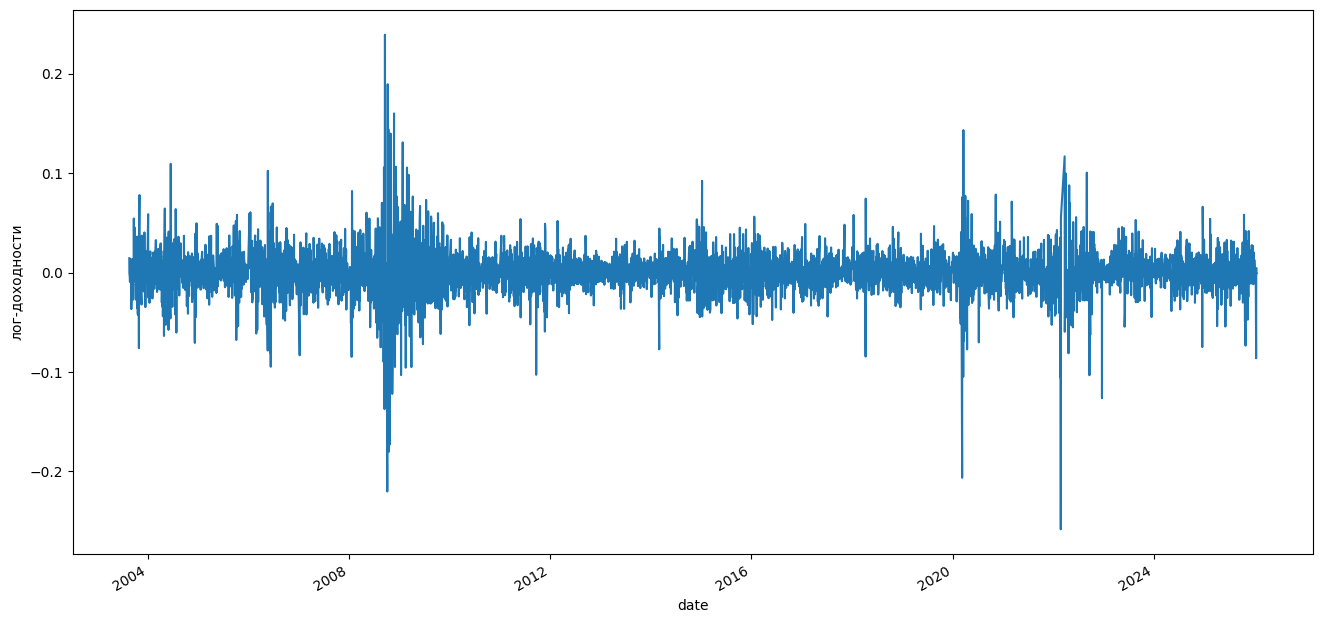

In [39]:
daily_returns = df['log_rtn']
_ = daily_returns.plot()
plt.ylabel('лог-доходности')
plt.rcParams['figure.figsize'] = [16, 8]
plt.show()


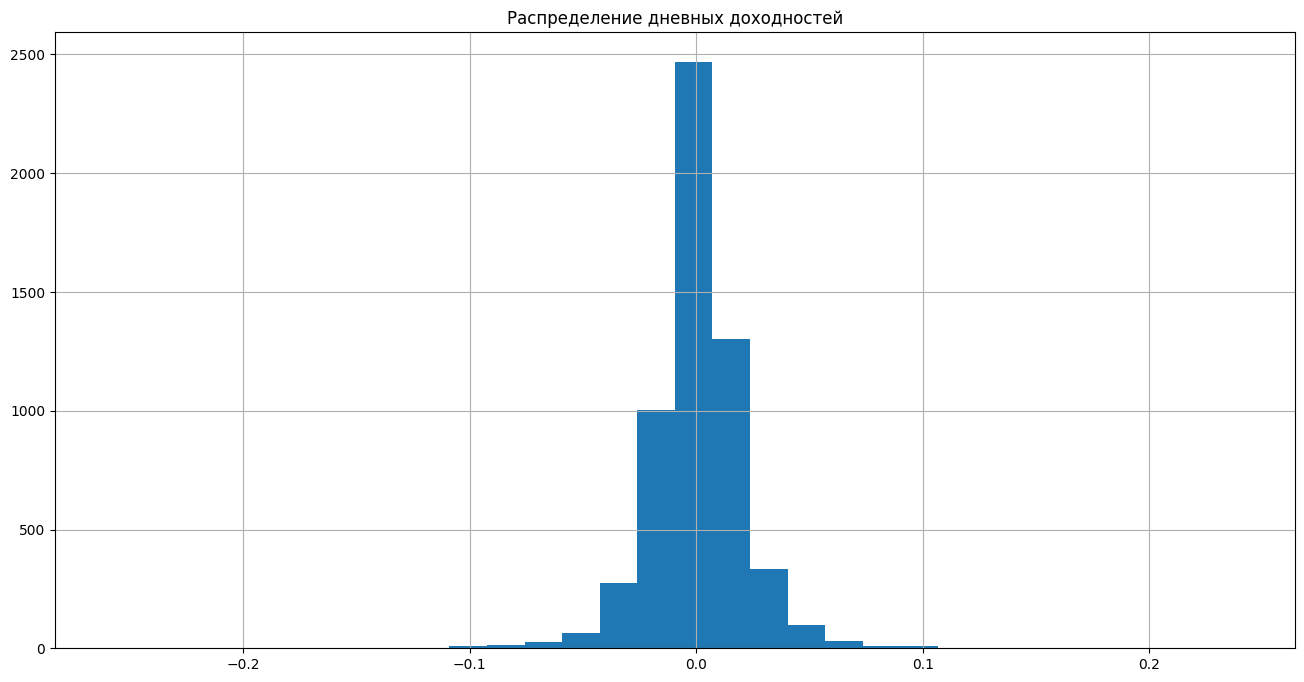

In [40]:
_ = daily_returns.hist(bins=30)
plt.title('Распределение дневных доходностей')
plt.show()


## Очистка данных ( data cleaning)

- **Корректировка цен**. Использование Adjusted Close (скорректированной цены закрытия), чтобы учесть корректно доходность. Это особенно важно на длинных горизонтах. 
- **Пропуски (NaN)**. Решение о том, удалять ли пропущенные строки (`dropna`) или заполнять их методами forward fill (предыдущим значением) или backward fill.
- **Ресемплирование**. Изменение частоты данных (например, из дневных цен в месячные или квартальные) с помощью метода .`resample()` для синхронизации разных датасетов.

### Обработка дивидендов и корпоративных действий

Дивиденды и дробления акций (сплит) влияют на цены и должны учитываться при анализе.

### Работа с данными дивидендов из russian_dividends

Проект [russian_dividends](https://github.com/quantviews/russian_dividends) предоставляет историю дивидендных выплат российских компаний в формате CSV.


In [ ]:
# Клонирование репозитория russian_dividends (если нужно)
# !git clone https://github.com/quantviews/russian_dividends.git

# Пример работы с данными дивидендов
# Предполагается, что CSV файлы уже загружены в папку data/

import os

# Путь к данным дивидендов
dividends_path = "russian_dividends/data"  # или другой путь

# Функция для загрузки дивидендов
def load_dividends(ticker, dividends_path="russian_dividends/data"):
    """
    Загружает данные о дивидендах для указанного тикера
    
    Parameters:
    ticker: тикер акции (например, 'SBER', 'GAZP')
    dividends_path: путь к папке с CSV файлами
    
    Returns:
    DataFrame с данными о дивидендах
    """
    csv_file = os.path.join(dividends_path, f"{ticker}.csv")
    
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file, parse_dates=['closing_date'])
        df.set_index('closing_date', inplace=True)
        return df
    else:
        print(f"Файл {csv_file} не найден")
        return pd.DataFrame()

# Пример использования
ticker_dividend = "SBER"
dividends_df = load_dividends(ticker_dividend, dividends_path)

if not dividends_df.empty:
    print(f"Дивиденды для {ticker_dividend}:")
    print(dividends_df.head(10))
    
    # Визуализация истории дивидендов
    plt.figure(figsize=(14, 6))
    plt.bar(dividends_df.index, dividends_df['dividend_value'], 
            alpha=0.7, color='green', edgecolor='black')
    plt.title(f'История дивидендов {ticker_dividend}')
    plt.xlabel('Дата закрытия реестра')
    plt.ylabel('Дивиденд на акцию (руб.)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Статистика по дивидендам
    print(f"\nСтатистика дивидендов {ticker_dividend}:")
    print(f"Средний дивиденд: {dividends_df['dividend_value'].mean():.2f} руб.")
    print(f"Максимальный дивиденд: {dividends_df['dividend_value'].max():.2f} руб.")
    print(f"Минимальный дивиденд: {dividends_df['dividend_value'].min():.2f} руб.")
    print(f"Всего выплат: {len(dividends_df)}")
else:
    print(f"Данные о дивидендах для {ticker_dividend} не найдены")
    print("Для получения данных выполните:")
    print("1. git clone https://github.com/quantviews/russian_dividends.git")
    print("2. python russian_dividends/dividend_parser.py SBER")


In [ ]:
# Анализ дивидендной доходности (dividend yield)
# Соединяем данные о ценах и дивидендах

def calculate_dividend_yield(price_data, dividends_data, ticker):
    """
    Рассчитывает дивидендную доходность
    
    Parameters:
    price_data: DataFrame с ценами акций
    dividends_data: DataFrame с данными о дивидендах
    ticker: тикер акции
    
    Returns:
    DataFrame с дивидендной доходностью
    """
    if dividends_data.empty or price_data.empty:
        return pd.DataFrame()
    
    # Берем цены закрытия
    if 'close' in price_data.columns:
        prices = price_data['close']
    else:
        prices = price_data.iloc[:, 0]  # Первая колонка
    
    # Создаем DataFrame с дивидендами по годам
    dividends_yearly = dividends_data.groupby('year')['dividend_value'].sum()
    
    # Рассчитываем дивидендную доходность для каждого года
    dividend_yield_data = []
    
    for year, dividend in dividends_yearly.items():
        # Находим цену в начале года
        year_prices = prices[prices.index.year == year]
        if not year_prices.empty:
            avg_price = year_prices.mean()
            if avg_price > 0:
                yield_pct = (dividend / avg_price) * 100
                dividend_yield_data.append({
                    'year': year,
                    'dividend': dividend,
                    'avg_price': avg_price,
                    'dividend_yield': yield_pct
                })
    
    return pd.DataFrame(dividend_yield_data)

# Пример расчета дивидендной доходности
if 'df_stock' in locals() and not dividends_df.empty:
    dividend_yield_df = calculate_dividend_yield(df_stock, dividends_df, ticker_dividend)
    
    if not dividend_yield_df.empty:
        print(f"\nДивидендная доходность {ticker_dividend}:")
        print(dividend_yield_df)
        
        # График дивидендной доходности
        plt.figure(figsize=(12, 6))
        plt.bar(dividend_yield_df['year'], dividend_yield_df['dividend_yield'], 
                alpha=0.7, color='blue', edgecolor='black')
        plt.title(f'Дивидендная доходность {ticker_dividend} по годам')
        plt.xlabel('Год')
        plt.ylabel('Дивидендная доходность (%)')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        print(f"\nСредняя дивидендная доходность: {dividend_yield_df['dividend_yield'].mean():.2f}%")


### Сравнение дивидендной политики нескольких компаний

Можно сравнить дивидендную политику разных компаний, используя данные из russian_dividends.


In [ ]:
# Сравнение дивидендной политики нескольких компаний
tickers_compare = ['SBER', 'GAZP', 'LKOH']  # Добавьте тикеры, для которых есть данные

dividends_comparison = {}

for ticker in tickers_compare:
    div_df = load_dividends(ticker, dividends_path)
    if not div_df.empty:
        # Группируем по годам
        yearly_dividends = div_df.groupby('year')['dividend_value'].sum()
        dividends_comparison[ticker] = yearly_dividends

if dividends_comparison:
    # Создаем DataFrame для сравнения
    dividends_comp_df = pd.DataFrame(dividends_comparison)
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # График 1: Абсолютные значения дивидендов
    dividends_comp_df.plot(kind='bar', ax=ax1, width=0.8)
    ax1.set_title('Сравнение дивидендных выплат по компаниям')
    ax1.set_xlabel('Год')
    ax1.set_ylabel('Дивиденд на акцию (руб.)')
    ax1.legend(title='Компания')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=45)
    
    # График 2: Тренд дивидендов
    dividends_comp_df.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=6)
    ax2.set_title('Тренд дивидендных выплат')
    ax2.set_xlabel('Год')
    ax2.set_ylabel('Дивиденд на акцию (руб.)')
    ax2.legend(title='Компания')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Статистика
    print("\nСравнительная статистика по дивидендам:")
    print(dividends_comp_df.describe())
    
    # Средние дивиденды
    print("\nСредние дивиденды по компаниям:")
    print(dividends_comp_df.mean().sort_values(ascending=False))
else:
    print("Данные о дивидендах не найдены. Убедитесь, что CSV файлы загружены.")


### Интеграция данных о дивидендах с ценами акций

Важно учитывать дивиденды при расчете общей доходности инвестиций.


In [ ]:
# Расчет общей доходности с учетом дивидендов
def calculate_total_return(price_data, dividends_data, start_date, end_date):
    """
    Рассчитывает общую доходность с учетом дивидендов
    
    Parameters:
    price_data: DataFrame с ценами
    dividends_data: DataFrame с дивидендами
    start_date: начальная дата
    end_date: конечная дата
    
    Returns:
    Словарь с метриками доходности
    """
    if price_data.empty:
        return {}
    
    # Фильтруем данные по периоду
    prices_filtered = price_data[(price_data.index >= start_date) & 
                                  (price_data.index <= end_date)]
    
    if prices_filtered.empty:
        return {}
    
    # Ценовая доходность
    if 'close' in prices_filtered.columns:
        price_start = prices_filtered['close'].iloc[0]
        price_end = prices_filtered['close'].iloc[-1]
    else:
        price_start = prices_filtered.iloc[0, 0]
        price_end = prices_filtered.iloc[-1, 0]
    
    price_return = (price_end - price_start) / price_start * 100
    
    # Дивидендная доходность
    dividends_filtered = dividends_data[
        (dividends_data.index >= start_date) & 
        (dividends_data.index <= end_date)
    ]
    
    total_dividends = dividends_filtered['dividend_value'].sum() if not dividends_filtered.empty else 0
    dividend_yield = (total_dividends / price_start) * 100 if price_start > 0 else 0
    
    # Общая доходность
    total_return = price_return + dividend_yield
    
    return {
        'price_return': price_return,
        'dividend_yield': dividend_yield,
        'total_dividends': total_dividends,
        'total_return': total_return,
        'price_start': price_start,
        'price_end': price_end
    }

# Пример расчета
if 'df_stock' in locals() and not dividends_df.empty:
    start_date = '2020-01-01'
    end_date = today
    
    returns_info = calculate_total_return(df_stock, dividends_df, start_date, end_date)
    
    if returns_info:
        print(f"\nАнализ доходности {ticker_dividend} за период {start_date} - {end_date}:")
        print(f"Начальная цена: {returns_info['price_start']:.2f} руб.")
        print(f"Конечная цена: {returns_info['price_end']:.2f} руб.")
        print(f"Ценовая доходность: {returns_info['price_return']:.2f}%")
        print(f"Выплачено дивидендов: {returns_info['total_dividends']:.2f} руб.")
        print(f"Дивидендная доходность: {returns_info['dividend_yield']:.2f}%")
        print(f"Общая доходность: {returns_info['total_return']:.2f}%")
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(10, 6))
        categories = ['Ценовая\nдоходность', 'Дивидендная\nдоходность', 'Общая\nдоходность']
        values = [returns_info['price_return'], returns_info['dividend_yield'], returns_info['total_return']]
        colors = ['blue', 'green', 'orange']
        
        bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('Доходность (%)')
        ax.set_title(f'Разложение доходности {ticker_dividend}')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Добавляем значения на столбцы
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()


### Обработка пропущенных данных и выбросов

При работе с финансовыми данными часто встречаются пропущенные значения и выбросы, которые могут исказить анализ.


In [ ]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df_index.isnull().sum())
print("\nПроцент пропущенных значений:")
print(df_index.isnull().sum() / len(df_index) * 100)


In [ ]:
# Методы обработки пропущенных значений
# 1. Удаление строк с пропусками
df_clean = df_index.dropna()

# 2. Заполнение пропусков (forward fill - последнее известное значение)
df_ffill = df_index.ffill()  # или df_index.fillna(method='ffill') в старых версиях

# 3. Заполнение пропусков (backward fill)
df_bfill = df_index.bfill()  # или df_index.fillna(method='bfill') в старых версиях

# 4. Интерполяция
df_interp = df_index.interpolate(method='linear')

print(f"Исходный размер: {len(df_index)}")
print(f"После dropna: {len(df_clean)}")
print(f"После ffill: {len(df_ffill)}")


In [ ]:
# Обнаружение выбросов с помощью IQR (Interquartile Range)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

if 'log_returns' in df_index.columns:
    outliers, lower, upper = detect_outliers_iqr(df_index, 'log_returns')
    print(f"Найдено {len(outliers)} выбросов")
    print(f"Нижняя граница: {lower:.4f}, Верхняя граница: {upper:.4f}")


## Визуализация данных о ценах акций

- Люди лучше воспринимают информацию графичеки (таблица или графика). 
- Визуально легко увидеть проблемы в данных - к примеру, дробления акций, приводящие к "падениям цен", часто не учитываются корректно в данных. Это также верно для ряда других свободно доступных источников данных. Поэтому лучше проверить!

Свечные графики (японские свечи) обычно используются на финансовых рынках для отображения движения ценной бумаги в течение периода времени. Они основаны на ценах открытия, максимума, минимума и закрытия ценной бумаги. Каждая свеча обычно показывает движение цены за один день, хотя свечи можно строить и за другие периоды.

По сравнению с графиками, представленными в предыдущей главе, свечные графики передают гораздо больше информации, чем простой линейный график скорректированной цены закрытия. Поэтому они часто используются на реальных торговых платформах.

Есть много способов создать свечной график в Python. Мы будем использовать `matplotlib` и `plotly`.

Перечислим некоторые библиотеки:

+ `matplotlib`
+ `plotly`
+ `ffn`


более чистый API


### Matplotlib /mpl

Matplotlib — стандартный способ построения графиков в Python. Но финансовые данные имеют свою специфику.

`mplfinance` — это обертка над библиотекой Matplotlib.


In [44]:
df

,open,close,high,low,value_rub,volume,ticker,simple_rtn,log_rtn
date,,,,,,,,,
2003-08-20,592.13,581.0,592.13,572.00,7.329184e+08,1264649.0,LKOH,NaN,NaN
2003-08-21,581.79,589.5,594.00,580.11,6.243343e+08,1063215.0,LKOH,0.014630,0.014524
2003-08-22,590.00,589.0,593.00,577.12,4.810764e+08,820377.0,LKOH,-0.000848,-0.000849
2003-08-25,590.00,586.5,591.99,583.00,2.390592e+08,407418.0,LKOH,-0.004244,-0.004254
2003-08-26,587.00,581.0,588.00,573.30,5.099564e+08,879803.0,LKOH,-0.009378,-0.009422
...,...,...,...,...,...,...,...,...,...
2026-01-09,5848.00,5878.0,5882.00,5821.00,3.543069e+09,605775.0,LKOH,0.004529,0.004519
2026-01-12,5520.00,5393.0,5550.00,5363.00,1.106989e+10,2022616.0,LKOH,-0.082511,-0.086115
2026-01-13,5385.00,5392.5,5430.00,5352.00,4.027574e+09,747154.0,LKOH,-0.000093,-0.000093


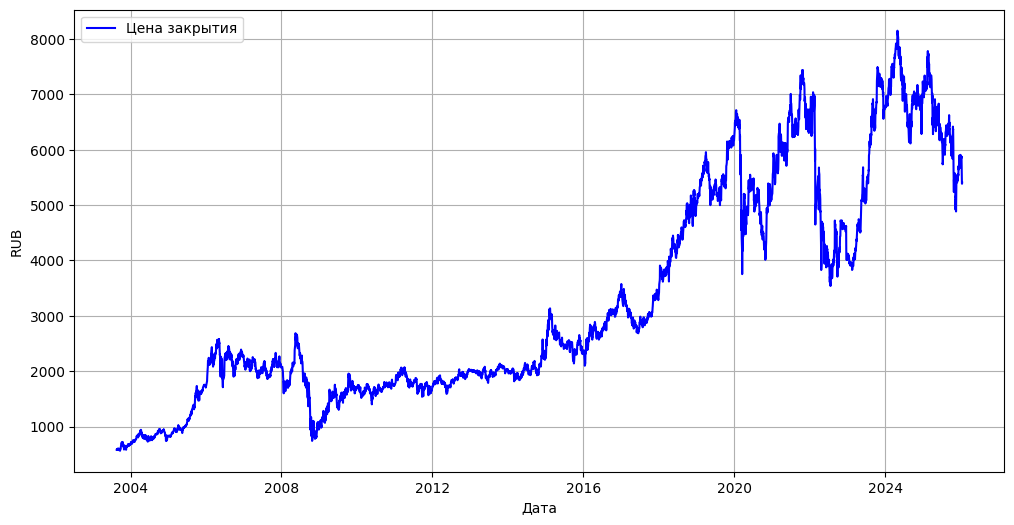

In [45]:
# Построим график цен закрытия
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='Цена закрытия', color='blue')
plt.xlabel('Дата')
plt.ylabel('RUB')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
mplfinance.plot(df.loc["2024"::],
            type='candle',
            style = 'charles',
            figsize=(16,8),
            volume = False,
            ylabel='RUB'
        )


NameError: name 'mplfinance' is not defined

### Plotly

интерактивная визуализация


In [48]:
import plotly.graph_objects as go

candlestick = go.Candlestick(
                            x     = df.index,
                            open  = df['open'],
                            high  = df['high'],
                            low   = df['low'],
                            close = df['close']
                            )

fig = go.Figure(data=[candlestick])
fig.show()


### ffn

Библиотека помогает получить доступ к портфелю и измерить производительность.


In [ ]:
# !pip install ffn
import ffn

In [ ]:
prices = ffn.get('aapl, msft', start='2010-01-01')

In [ ]:
ax = prices.rebase().plot(figsize=(16, 8))

In [ ]:
prices

In [ ]:
# хорошо, а что насчет метрик производительности?
stats = prices.calc_stats()
stats.display()


## Риск и доходность

Компромисс риск-доходность означает, что инвесторы ожидают более высокой доходности в качестве компенсации за принятие более высокого риска. Этот принцип формирует инвестиционные стратегии:

- Инвестиции с низким риском и низкой доходностью. Примеры: государственные облигации, сберегательные счета. Инвесторы принимают более низкую доходность, потому что эти активы воспринимаются как более безопасные.
- Инвестиции с высоким риском и высокой доходностью. Примеры: акции, товары, венчурный капитал. Эти активы предлагают более высокую потенциальную доходность, но сопряжены с более высоким шансом потерь.


Метрики риска:

- Стандартное отклонение: Измеряет волатильность; более высокие значения указывают на более высокий риск.
- Value at Risk (VaR): Оценивает потенциальные потери за заданный период времени.
- Бета: Измеряет чувствительность актива к движениям рынка (систематический риск).


In [ ]:
df_index


In [ ]:
# 1. Рассчитаем лог-доходности
df_index['log_returns'] = np.log(df_index['close'] / df_index['close'].shift(1))
df_index.index = pd.to_datetime(df_index.index)

# 2. Извлечем год из индекса

df_index['year'] = df_index.index.year

# 3. Рассчитаем стандартное отклонение лог-доходностей для каждого года
yearly_std = df_index.groupby('year')['log_returns'].std() * np.sqrt(252)

# Выведем результаты
print("Стандартное отклонение лог-доходностей для каждого года:")
print(yearly_std)


In [ ]:
# 3. Рассчитаем годовые доходности лог-доходностей для каждого года
yearly_rtns = df_index.groupby('year')['log_returns'].sum()

# Выведем результаты
print("Годовые лог-доходности для каждого года:")
print(yearly_rtns)


In [ ]:
merged_df = pd.merge(yearly_rtns, yearly_std, on='year')


In [ ]:
merged_df = merged_df.rename(columns = {"log_returns_x": "annual_return", "log_returns_y": "std_deviation"}).copy()


In [ ]:
merged_df['year'] = merged_df.index


In [ ]:
merged_df['year']


In [ ]:
# Создадим диаграмму рассеяния
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['std_deviation'], merged_df['annual_return'], color='blue', alpha=0.7)

# Добавим подписи и заголовок
plt.title('Годовые доходности vs. Стандартное отклонение', fontsize=14)
plt.xlabel('Стандартное отклонение', fontsize=12)
plt.ylabel('Годовая доходность', fontsize=12)

# Добавим метки года к каждой точке используя .iloc
for i in range(len(merged_df)):
    std = merged_df.iloc[i]['std_deviation']
    rtn = merged_df.iloc[i]['annual_return']
    year = merged_df.iloc[i]['year']
    plt.text(std, rtn, str(int(year)), fontsize=10, ha='right')

# Отобразим график
plt.grid(True, linestyle='-', alpha=0.5)
plt.show()


## Показатель Херста

**Показатель Херста (H)** — это статистическая мера, используемая для оценки долгосрочной памяти или фрактальных характеристик временного ряда. Он количественно определяет степень персистентности, случайности или антиперсистентности в данных. Он назван в честь Гарольда Эдвина Херста, который ввел его в контексте гидрологии для изучения уровней воды в реке Нил.

Обнаружение трендов рынка или возврата к среднему:
- $𝐻>0.5$.  Трендовый рынок. Акции, показывающие персистентность, могут указывать на продолжение трендов, полезно для стратегий моментума.
- $𝐻<0.5$. Рынок с возвратом к среднему. Это полезно для парного трейдинга, арбитража или контрарианских стратегий.
- $𝐻≈0.5$. Случайное блуждание, подразумевающее чисто стохастический процесс, где предсказание затруднено.


Показатель Херста основан на идее самоподобия или масштабной инвариантности, распространенной во фрактальной геометрии. Фрактальный объект выглядит похожим на разных масштабах, и временные ряды с памятью часто показывают похожие статистические паттерны на разных временных горизонтах.

В финансовых временных рядах масштабная инвариантность означает, что паттерны в изменениях цен (например, тренды или волатильность), наблюдаемые на коротких периодах, могут сохраняться на более длительных временных масштабах.
Показатель Херста помогает количественно определить, являются ли эти паттерны согласованными, персистентными или случайными на разных масштабах.


In [ ]:
def get_hurst_exponent(ts, max_lag=20):
    """Возвращает показатель Херста временного ряда"""
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    hurst_exp = np.polyfit(np.log(lags), np.log(tau), 1)[0]
    return hurst_exp


In [ ]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = get_hurst_exponent(df_index["close"].values, lag)
    print(f"Показатель Херста с {lag} лагами: {hurst_exp:.4f}")


## Статистические тесты

Перед моделированием важно проверить свойства данных: стационарность, нормальность распределения.


In [ ]:
# Тест на нормальность (Shapiro-Wilk для малых выборок, Jarque-Bera для больших)
from scipy import stats

if 'log_rtn' in df.columns:
    returns_sample = df['log_rtn'].dropna()[:5000]  # Берем первые 5000 для теста
    
    # Shapiro-Wilk тест (для выборок < 5000)
    if len(returns_sample) < 5000:
        stat, p_value = stats.shapiro(returns_sample)
        print(f"Shapiro-Wilk тест: статистика={stat:.4f}, p-value={p_value:.4f}")
        print(f"Нормальное распределение: {'Да' if p_value > 0.05 else 'Нет'}")
    
    # Jarque-Bera тест (для больших выборок)
    jb_stat, jb_pvalue = stats.jarque_bera(returns_sample)
    print(f"\nJarque-Bera тест: статистика={jb_stat:.4f}, p-value={jb_pvalue:.4f}")
    print(f"Нормальное распределение: {'Да' if jb_pvalue > 0.05 else 'Нет'}")


In [ ]:
# Тест на стационарность (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller

if 'log_rtn' in df.columns:
    returns_clean = df['log_rtn'].dropna()
    
    # Тест ADF
    result = adfuller(returns_clean)
    print('ADF Статистика:', result[0])
    print('p-value:', result[1])
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    print(f"\nРяд стационарен: {'Да' if result[1] < 0.05 else 'Нет'}")


## Технические индикаторы

Технические индикаторы помогают анализировать тренды и принимать торговые решения.


In [ ]:
# Скользящие средние (Moving Averages)
if 'close' in df.columns:
    df['MA_20'] = df['close'].rolling(window=20).mean()
    df['MA_50'] = df['close'].rolling(window=50).mean()
    df['MA_200'] = df['close'].rolling(window=200).mean()
    
    # Построим график
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['close'], label='Цена закрытия', alpha=0.7)
    plt.plot(df.index, df['MA_20'], label='MA 20', linewidth=1.5)
    plt.plot(df.index, df['MA_50'], label='MA 50', linewidth=1.5)
    plt.plot(df.index, df['MA_200'], label='MA 200', linewidth=1.5)
    plt.title('Цена и скользящие средние')
    plt.xlabel('Дата')
    plt.ylabel('Цена')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# RSI (Relative Strength Index)
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

if 'close' in df.columns:
    df['RSI'] = calculate_rsi(df['close'])
    
    # График RSI
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    ax1.plot(df.index, df['close'], label='Цена закрытия')
    ax1.set_ylabel('Цена')
    ax1.set_title('Цена и RSI')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df.index, df['RSI'], label='RSI', color='orange')
    ax2.axhline(y=70, color='r', linestyle='--', label='Перекупленность (70)')
    ax2.axhline(y=30, color='g', linestyle='--', label='Перепроданность (30)')
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Дата')
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# MACD (Moving Average Convergence Divergence)
def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

if 'close' in df.columns:
    macd, signal, hist = calculate_macd(df['close'])
    df['MACD'] = macd
    df['MACD_signal'] = signal
    df['MACD_hist'] = hist
    
    # График MACD
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    ax1.plot(df.index, df['close'], label='Цена закрытия')
    ax1.set_ylabel('Цена')
    ax1.set_title('Цена и MACD')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df.index, macd, label='MACD', color='blue')
    ax2.plot(df.index, signal, label='Signal', color='red')
    ax2.bar(df.index, hist, label='Histogram', alpha=0.3, color='gray')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_ylabel('MACD')
    ax2.set_xlabel('Дата')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Корреляционный анализ

Корреляция помогает понять взаимосвязи между активами.


In [ ]:
# Загрузим данные по нескольким акциям для анализа корреляции
if 'session' in locals():
    tickers = ['SBER', 'GAZP', 'LKOH', 'GMKN']
    prices_dict = {}
    
    for ticker in tickers:
        try:
            data = apimoex.get_market_candles(session=session, security=ticker, 
                                            interval=24, start='2023-01-01', end=today)
            df_temp = pd.DataFrame(data)
            if not df_temp.empty:
                df_temp['begin'] = pd.to_datetime(df_temp['begin'])
                df_temp.set_index('begin', inplace=True)
                prices_dict[ticker] = df_temp['close']
        except Exception as e:
            print(f"Не удалось загрузить данные для {ticker}: {e}")
    
    if prices_dict:
        # Создаем DataFrame с ценами
        prices_multi = pd.DataFrame(prices_dict)
        
        # Рассчитываем корреляцию доходностей
        returns_multi = prices_multi.pct_change().dropna()
        correlation_matrix = returns_multi.corr()
        
        # Визуализация корреляционной матрицы
        try:
            import seaborn as sns
            plt.figure(figsize=(10, 8))
            sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, linewidths=1)
            plt.title('Корреляционная матрица доходностей')
            plt.tight_layout()
            plt.show()
        except ImportError:
            # Если seaborn не установлен, используем matplotlib
            plt.figure(figsize=(10, 8))
            plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
            plt.colorbar()
            plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
            plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
            plt.title('Корреляционная матрица доходностей')
            plt.tight_layout()
            plt.show()
        
        print("\nКорреляционная матрица:")
        print(correlation_matrix)


## Дополнительные ресурсы

### Полезные библиотеки и проекты:

- **[moexutils](https://github.com/quantviews/moexutils)** - Утилиты для работы с MOEX API
- **[russian_dividends](https://github.com/quantviews/russian_dividends)** - История дивидендных выплат российских компаний
- [Документация yfinance](https://github.com/ranaroussi/yfinance)
- [Документация apimoex](https://github.com/WLM1ke/apimoex)
- [Pandas документация по временным рядам](https://pandas.pydata.org/docs/user_guide/timeseries.html)
- [Статистические тесты в scipy](https://docs.scipy.org/doc/scipy/reference/stats.html)
